# Angular & Bond-Length Distribution Functions

This notebook demonstrates two complementary distribution functions
available in pyscal:

* **Angular Distribution Function (ADF)** — histogram of all bond angles
  $\theta_{jik}$ formed by pairs of neighbors around each atom.
* **Bond-Length Distribution Function (BLDF)** — histogram of all
  neighbor distances (similar to the RDF but without shell-volume
  normalisation).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyscal as pc
from ase.build import bulk

## 1. FCC Aluminium

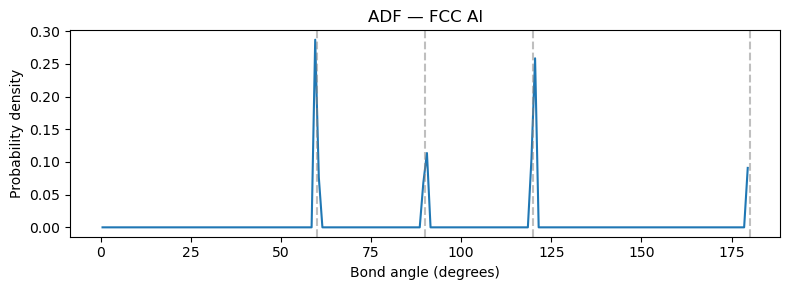

In [2]:
al = bulk("Al", cubic=True).repeat(4)
pc.find_neighbors(al, method="cutoff", cutoff=0)

adf, angles = pc.angular_distribution_function(al, bins=180)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(angles + 0.5, adf)
ax.set_xlabel("Bond angle (degrees)")
ax.set_ylabel("Probability density")
ax.set_title("ADF — FCC Al")
for a in [60, 90, 120, 180]:
    ax.axvline(a, ls="--", color="grey", alpha=0.5)
plt.tight_layout()
plt.show()

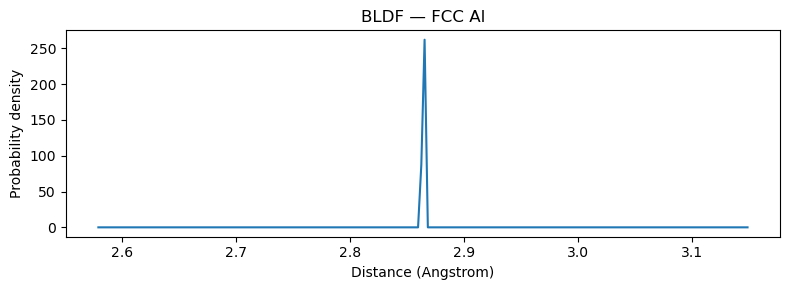

In [3]:
bldf, r = pc.bond_length_distribution(al, bins=200)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(r + (r[1] - r[0]) / 2, bldf)
ax.set_xlabel("Distance (Angstrom)")
ax.set_ylabel("Probability density")
ax.set_title("BLDF — FCC Al")
plt.tight_layout()
plt.show()

## 2. BCC Iron

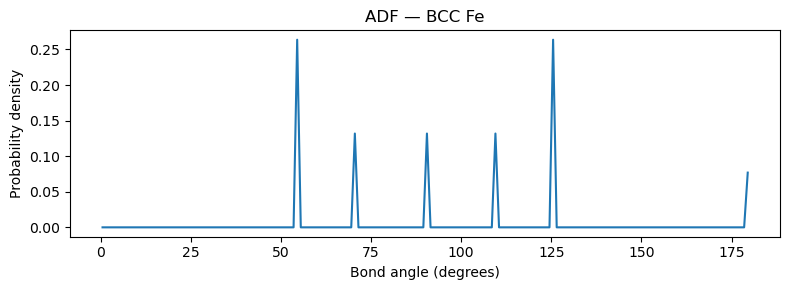

In [4]:
fe = bulk("Fe", cubic=True).repeat(4)
pc.find_neighbors(fe, method="cutoff", cutoff=0)

adf_bcc, angles = pc.angular_distribution_function(fe, bins=180)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(angles + 0.5, adf_bcc)
ax.set_xlabel("Bond angle (degrees)")
ax.set_ylabel("Probability density")
ax.set_title("ADF — BCC Fe")
plt.tight_layout()
plt.show()

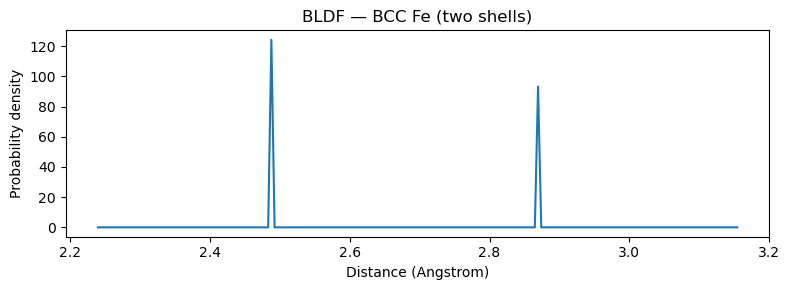

In [5]:
bldf_bcc, r_bcc = pc.bond_length_distribution(fe, bins=200)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(r_bcc + (r_bcc[1] - r_bcc[0]) / 2, bldf_bcc)
ax.set_xlabel("Distance (Angstrom)")
ax.set_ylabel("Probability density")
ax.set_title("BLDF — BCC Fe (two shells)")
plt.tight_layout()
plt.show()

## 3. Comparing FCC vs HCP angular fingerprints

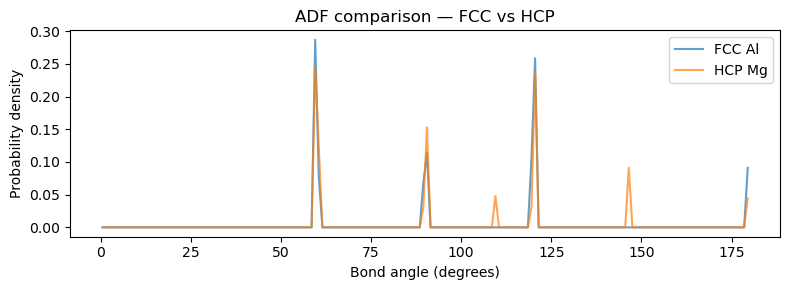

In [6]:
mg = bulk("Mg", "hcp", a=3.21, c=5.21).repeat((4, 4, 3))
pc.find_neighbors(mg, method="cutoff", cutoff=0)

adf_hcp, ang_hcp = pc.angular_distribution_function(mg, bins=180)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(angles + 0.5, adf, label="FCC Al", alpha=0.7)
ax.plot(ang_hcp + 0.5, adf_hcp, label="HCP Mg", alpha=0.7)
ax.set_xlabel("Bond angle (degrees)")
ax.set_ylabel("Probability density")
ax.set_title("ADF comparison — FCC vs HCP")
ax.legend()
plt.tight_layout()
plt.show()

## Summary

| Function | What it measures | Normalisation |
|----------|-----------------|---------------|
| `angular_distribution_function` | All bond angles $\theta_{jik}$ | Probability density |
| `bond_length_distribution` | All neighbor distances | Probability density |
| `radial_distribution_function` | Radial pair distances | Shell-volume normalised |

The ADF is particularly useful for distinguishing crystal structures that
share the same coordination number (e.g., FCC vs HCP, both CN=12) but
differ in angular arrangement.